In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

project_dir = os.path.dirname(os.getcwd())  
cur_file = os.path.join(project_dir, "data", "shipment.csv")

df = pd.read_csv(cur_file)
df['date'] = pd.to_datetime(df['date'])

df['is_delayed'] = (df['delay_minutes'] > 0).astype(int)

daily = df.groupby('date')['is_delayed'].mean().reset_index()
daily.rename(columns={'is_delayed': 'delay_rate'}, inplace=True)


In [2]:
daily['dayofweek'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['rolling_mean_7'] = daily['delay_rate'].rolling(window=7, min_periods=1).mean()
daily['rolling_mean_14'] = daily['delay_rate'].rolling(window=14, min_periods=1).mean()

daily['target'] = daily['delay_rate'].shift(-1)
daily = daily.dropna()


In [3]:
train = daily.iloc[:-7]
test = daily.iloc[-7:]

X_train = train[['dayofweek', 'month', 'rolling_mean_7', 'rolling_mean_14']]
y_train = train['target']
X_test = test[['dayofweek', 'month', 'rolling_mean_7', 'rolling_mean_14']]
y_test = test['target']
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | MAE = {mae:.4f} | R² = {r2:.4f}")


In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [5]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(verbose=0, random_state=42)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)


In [6]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(random_state=42)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 520
[LightGBM] [Info] Number of data points in the train set: 1028, number of used features: 4
[LightGBM] [Info] Start training from score 0.826057


In [7]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.4f}, R2={r2:.4f}")

evaluate("LinearRegression", y_test, y_pred_lr)
evaluate("CatBoost", y_test, y_pred_cat)
evaluate("LightGBM", y_test, y_pred_lgb)


LinearRegression: MAE=0.2047, R2=-0.0816
CatBoost: MAE=0.2175, R2=0.0643
LightGBM: MAE=0.2294, R2=-0.1637


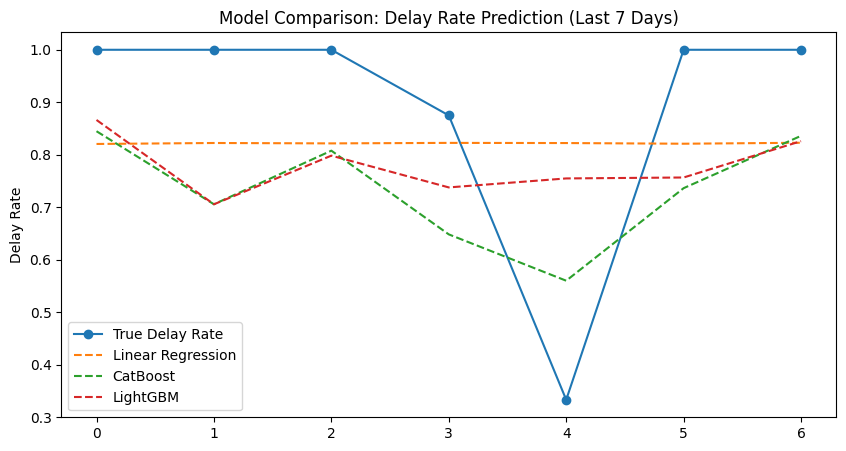

In [8]:
future = daily.copy()
for i in range(7):
    last_row = future.iloc[-1].copy()
    new_date = last_row['date'] + pd.Timedelta(days=1)
    new_row = {
        'date': new_date,
        'dayofweek': new_date.dayofweek,
        'month': new_date.month,
        'rolling_mean_7': future['delay_rate'].iloc[-7:].mean(),
        'rolling_mean_14': future['delay_rate'].iloc[-14:].mean(),
    }

    X_new = pd.DataFrame([new_row])[['dayofweek', 'month', 'rolling_mean_7', 'rolling_mean_14']]
    pred = cat.predict(X_new)[0]  
    new_row['delay_rate'] = pred
    future = pd.concat([future, pd.DataFrame([new_row])], ignore_index=True)

forecast = future.tail(7)[['date', 'delay_rate']]
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="True Delay Rate", marker='o')
plt.plot(y_pred_lr, label="Linear Regression", linestyle='--')
plt.plot(y_pred_cat, label="CatBoost", linestyle='--')
plt.plot(y_pred_lgb, label="LightGBM", linestyle='--')
plt.title("Model Comparison: Delay Rate Prediction (Last 7 Days)")
plt.ylabel("Delay Rate")
plt.legend()
plt.show()

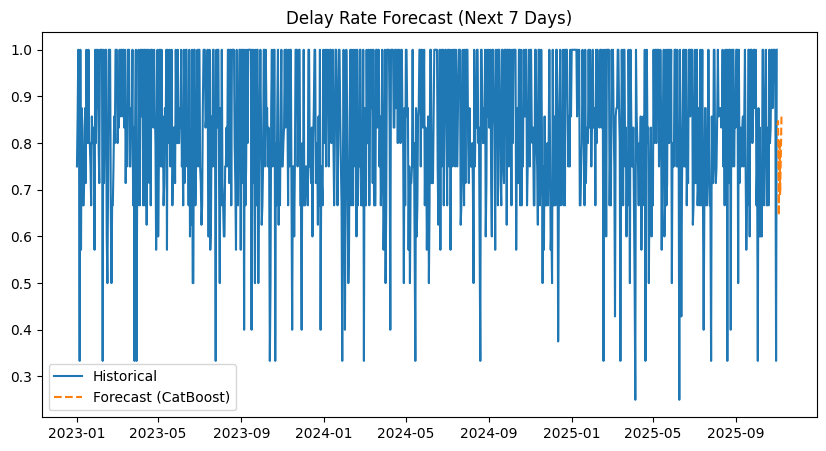

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily['date'], daily['delay_rate'], label='Historical')
plt.plot(forecast['date'], forecast['delay_rate'], label='Forecast (CatBoost)', linestyle='--')
plt.title("Delay Rate Forecast (Next 7 Days)")
plt.legend()
plt.show()


# USING CURRENT MONTH AND BEFORE MONTH

In [10]:
from datetime import datetime, timedelta

today = datetime.today()

current_month = today.month
current_year = today.year

if current_month == 1:
    prev_month = 12
    prev_year = current_year - 1
else:
    prev_month = current_month - 1
    prev_year = current_year


In [11]:
df['date'] = pd.to_datetime(df['date'])
cur_month_df = df[df['date'].dt.month == current_month]

prev_month_df = df[df['date'].dt.month == prev_month]

filtered_df = pd.concat([cur_month_df, prev_month_df])

print(filtered_df['date'].min(), '→', filtered_df['date'].max())
print(f"Total rows used for training: {len(filtered_df)}")

filtered_df.head()

2023-10-01 00:00:00 → 2025-11-01 00:00:00
Total rows used for training: 814


,id,route,warehouse,delivery_time,delay_minutes,delay_reason,date,is_delayed
1700,1701,Route D,WH3,4.8,105,Traffic,2023-11-01,1
1701,1702,Route B,WH1,5.3,86,Weather,2023-11-01,1
1702,1703,Route A,WH2,6.5,50,Traffic,2023-11-01,1
1703,1704,Route C,WH4,3.8,0,NaN,2023-11-01,0
1704,1705,Route D,WH2,5.8,32,Accident,2023-11-02,1


In [12]:
filtered_df['is_delayed'] = (filtered_df['delay_minutes'] > 0).astype(int)

daily = filtered_df.groupby('date')['is_delayed'].mean().reset_index()
daily.rename(columns={'is_delayed': 'delay_rate'}, inplace=True)

daily['dayofweek'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['rolling_mean_7'] = daily['delay_rate'].rolling(window=7, min_periods=1).mean()
daily['rolling_mean_14'] = daily['delay_rate'].rolling(window=14, min_periods=1).mean()
daily['target'] = daily['delay_rate'].shift(-1)
daily = daily.dropna()


In [13]:


train = daily.iloc[:-7]
test = daily.iloc[-7:]

X_train = train[['dayofweek', 'month', 'rolling_mean_7', 'rolling_mean_14']]
y_train = train['target']
X_test = test[['dayofweek', 'month', 'rolling_mean_7', 'rolling_mean_14']]
y_test = test['target']



In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)




In [15]:
cat = CatBoostRegressor(verbose=0, random_state=42, depth=6, learning_rate=0.05, iterations=500)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)



In [16]:
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)



Linear Regression    | MAE = 0.2013 | R² = -0.0204
CatBoost Regressor   | MAE = 0.2342 | R² = -0.1764
Gradient Boosting    | MAE = 0.2650 | R² = -0.7121

 Best model: Linear Regression (lowest MAE = 0.2013)


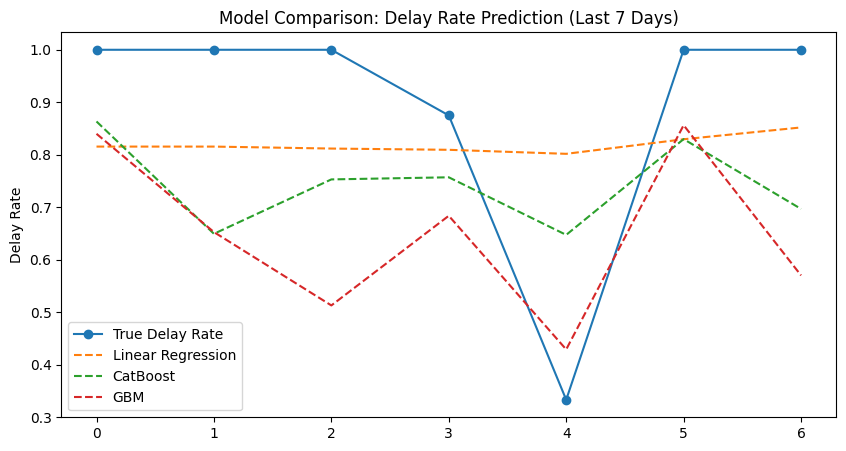

In [17]:

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | MAE = {mae:.4f} | R² = {r2:.4f}")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("CatBoost Regressor", y_test, y_pred_cat)
evaluate("Gradient Boosting", y_test, y_pred_gbm)

# --- Choose best model (lowest MAE) ---
import numpy as np

results = {
    "Linear Regression": mean_absolute_error(y_test, y_pred_lr),
    "CatBoost Regressor": mean_absolute_error(y_test, y_pred_cat),
    "Gradient Boosting": mean_absolute_error(y_test, y_pred_gbm),
}

best_model_name = min(results, key=results.get)
print(f"\n Best model: {best_model_name} (lowest MAE = {results[best_model_name]:.4f})")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="True Delay Rate", marker='o')
plt.plot(y_pred_lr, label="Linear Regression", linestyle='--')
plt.plot(y_pred_cat, label="CatBoost", linestyle='--')
plt.plot(y_pred_gbm, label="GBM", linestyle='--')
plt.title("Model Comparison: Delay Rate Prediction (Last 7 Days)")
plt.ylabel("Delay Rate")
plt.legend()
plt.show()

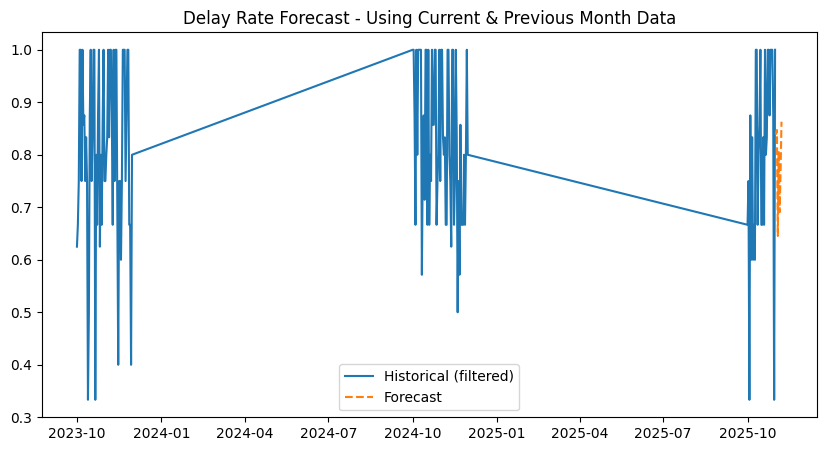

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily['date'], daily['delay_rate'], label='Historical (filtered)')
plt.plot(forecast['date'], forecast['delay_rate'], label='Forecast', linestyle='--')
plt.title("Delay Rate Forecast - Using Current & Previous Month Data")
plt.legend()
plt.show()
